In [1]:
library(tidyverse)
library(fixest)   
library(data.table)
library(broom)
library(dplyr)
library(ggplot2)
library(readr)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Adjuntando el paquete: 'data.table'


The following objects are masked from 'package:lubridate':

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from 'package:dplyr':

    between, first, last


The following object is masked from 'package:purrr':

    transpose




# Question 1 — TWFE & Event-Study

## a) TWFE

In [2]:
data <- read.csv("C:/Users/VICTOR/Documents/GitHub/CSDiD/R/Input/bacon_example.csv")
head(data)
str(data)
twfe_model <- feols(asmrs ~ post + pcinc + asmrh + cases | 
                    stfips + year, 
                    data = data)

cat("\n=== RESULTADOS TWFE ===\n")
summary(twfe_model)

,stfips,year,X_nfd,post,asmrs,pcinc,asmrh,cases,weight,copop
,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,1964,1971,0,35.63988,12406.18,5.007341,0.012312243,1715156,1715156
2,1,1965,1971,0,41.54375,13070.21,4.425367,0.010419407,1715156,1725186
3,1,1966,1971,0,34.25233,13526.66,4.874819,0.009900097,1715156,1735219
4,1,1967,1971,0,34.46502,13918.19,5.362014,0.009974692,1715156,1745250
5,1,1968,1971,0,40.44011,14684.81,4.643759,0.012400659,1715156,1755283
6,1,1969,1971,0,42.49012,15638.88,5.296976,0.015006756,1715156,1765316


'data.frame':	1617 obs. of  10 variables:
 $ stfips: int  1 1 1 1 1 1 1 1 1 1 ...
 $ year  : int  1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 ...
 $ X_nfd : int  1971 1971 1971 1971 1971 1971 1971 1971 1971 1971 ...
 $ post  : int  0 0 0 0 0 0 0 1 1 1 ...
 $ asmrs : num  35.6 41.5 34.3 34.5 40.4 ...
 $ pcinc : num  12406 13070 13527 13918 14685 ...
 $ asmrh : num  5.01 4.43 4.87 5.36 4.64 ...
 $ cases : num  0.01231 0.01042 0.0099 0.00997 0.0124 ...
 $ weight: num  1715156 1715156 1715156 1715156 1715156 ...
 $ copop : num  1715156 1725186 1735219 1745250 1755283 ...

=== RESULTADOS TWFE ===


OLS estimation, Dep. Var.: asmrs
Observations: 1,617
Fixed-effects: stfips: 49,  year: 33
Standard-errors: IID 
         Estimate Std. Error  t value   Pr(>|t|)    
post    -2.515964   1.099745 -2.28777 2.2287e-02 *  
pcinc   -0.001118   0.000206 -5.41653 7.0463e-08 ***
asmrh    1.184598   0.315274  3.75736 1.7815e-04 ***
cases -178.517916  53.939505 -3.30960 9.5601e-04 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 10.6     Adj. R2: 0.693695
             Within R2: 0.034601

## b) Cleaning


=== TABLA DE FRECUENCIAS DE EVENT_TIME ===
# A tibble: 50 × 2
   event_time     n
        <int> <int>
 1        -21     1
 2        -20     2
 3        -19     2
 4        -18     2
 5        -17     2
 6        -16     3
 7        -15     3
 8        -14     3
 9        -13     6
10        -12     7
# ℹ 40 more rows

=== RESUMEN DESCRIPTIVO ===
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
-21.000  -2.000   6.000   6.417  15.000  27.000     264 


Warning message:
"Removed 264 rows containing non-finite outside the scale range (`stat_count()`)."


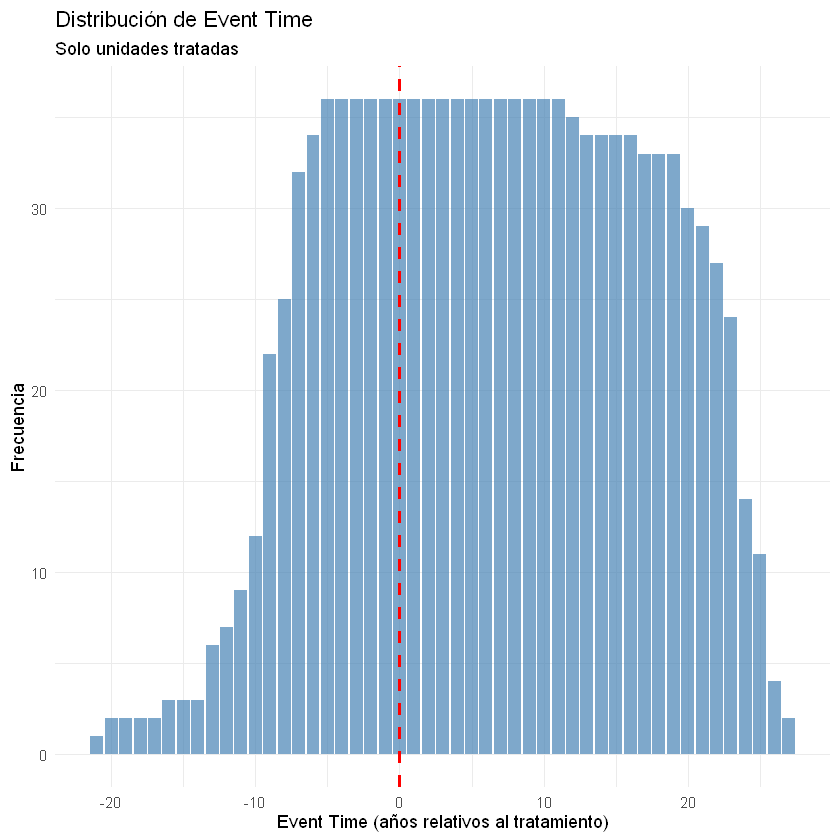

In [3]:
data <- data %>%
  mutate(
    event_time = year - X_nfd,
    ever_treated = ifelse(any(post == 1), 1, 0)
  ) %>%
  group_by(stfips) %>%
  mutate(ever_treated = max(post)) %>%  
  ungroup()

data_treated <- data %>% filter(ever_treated == 1)

freq_table <- data_treated %>%
  count(event_time) %>%
  arrange(event_time)

cat("\n=== TABLA DE FRECUENCIAS DE EVENT_TIME ===\n")
print(freq_table)

cat("\n=== RESUMEN DESCRIPTIVO ===\n")
print(summary(data_treated$event_time))

dist_plot <- ggplot(data_treated, aes(x = event_time)) +
  geom_bar(fill = "steelblue", alpha = 0.7) +
  labs(title = "Distribución de Event Time",
       subtitle = "Solo unidades tratadas",
       x = "Event Time (años relativos al tratamiento)",
       y = "Frecuencia") +
  theme_minimal() +
  geom_vline(xintercept = 0, linetype = "dashed", color = "red", linewidth = 1)

print(dist_plot)

min_et <- min(data_treated$event_time)
max_et <- max(data_treated$event_time)

lower_bound <- -10
upper_bound <- 20

> Respuesta: Se agrupan los tiempos mas lejanos porque en los extremos suelen quedar pocas observaciones, lo cual genera ruido en las estimaciones: intervalos de confianza grandes

In [4]:
data_treated <- data_treated %>%
  mutate(event_time_binned = case_when(
    event_time < lower_bound ~ lower_bound,
    event_time > upper_bound ~ upper_bound,
    TRUE ~ event_time
  ))

cat("\n=== DISTRIBUCIÓN DE EVENT_TIME_BINNED ===\n")
print(table(data_treated$event_time_binned))

event_times <- sort(unique(data_treated$event_time_binned))

for(et in event_times) {
  if(et != -1) {  
    var_name <- paste0("event_time_", ifelse(et < 0, "m", "p"), abs(et))
    data_treated[[var_name]] <- as.numeric(data_treated$event_time_binned == et)
  }
}
cat("\nDummies creadas para event_time (excepto -1 como referencia)\n")


=== DISTRIBUCIÓN DE EVENT_TIME_BINNED ===

-10  -9  -8  -7  -6  -5  -4  -3  -2  -1   0   1   2   3   4   5   6   7   8   9 
 52  22  25  32  34  36  36  36  36  36  36  36  36  36  36  36  36  36  36  36 
 10  11  12  13  14  15  16  17  18  19  20 
 36  36  35  34  34  34  34  33  33  33 141 

Dummies creadas para event_time (excepto -1 como referencia)


## c) Event Study

NOTE: 264 observations removed because of NA values (RHS: 264).




=== RESULTADOS EVENT-STUDY ===


OLS estimation, Dep. Var.: asmrs
Observations: 1,188
Fixed-effects: stfips: 36,  year: 33
Standard-errors: IID 
                          Estimate Std. Error   t value  Pr(>|t|)    
event_time_binned::-10   -2.359212   5.390432 -0.437667 0.6617150    
event_time_binned::-9    -4.847496   4.497646 -1.077785 0.2813688    
event_time_binned::-8    -2.255540   4.130034 -0.546131 0.5850879    
event_time_binned::-7    -0.859273   3.722035 -0.230861 0.8174661    
event_time_binned::-6    -0.591950   3.444860 -0.171836 0.8635986    
event_time_binned::-5    -2.570204   3.142245 -0.817951 0.4135642    
event_time_binned::-4     0.292826   2.958491  0.098978 0.9211738    
event_time_binned::-3    -2.528794   2.759812 -0.916292 0.3597168    
event_time_binned::-2    -0.345114   2.688771 -0.128354 0.8978928    
event_time_binned::0      0.914360   2.689453  0.339980 0.7339373    
event_time_binned::1     -0.894402   2.757530 -0.324349 0.7457364    
event_time_binned::2     -0.132999   2.959081 -0

[1] "Coeficientes del Event-Study:"
                       event_time coefficient       se   ci_lower ci_upper
event_time_binned::-10        -10  -2.3592119 5.390432 -12.924459 8.206035
event_time_binned::-9          -9  -4.8474958 4.497646 -13.662882 3.967890
event_time_binned::-8          -8  -2.2555397 4.130034 -10.350406 5.839327
event_time_binned::-7          -7  -0.8592734 3.722035  -8.154463 6.435916
event_time_binned::-6          -6  -0.5919504 3.444860  -7.343875 6.159975
event_time_binned::-5          -5  -2.5702040 3.142245  -8.729005 3.588597
event_time_binned::-4          -4   0.2928260 2.958491  -5.505816 6.091468
event_time_binned::-3          -3  -2.5287942 2.759812  -7.938025 2.880437
event_time_binned::-2          -2  -0.3451137 2.688771  -5.615105 4.924878
1                              -1   0.0000000 0.000000   0.000000 0.000000
event_time_binned::0            0   0.9143601 2.689453  -4.356969 6.185689
event_time_binned::1            1  -0.8944017 2.757530  -6.29916

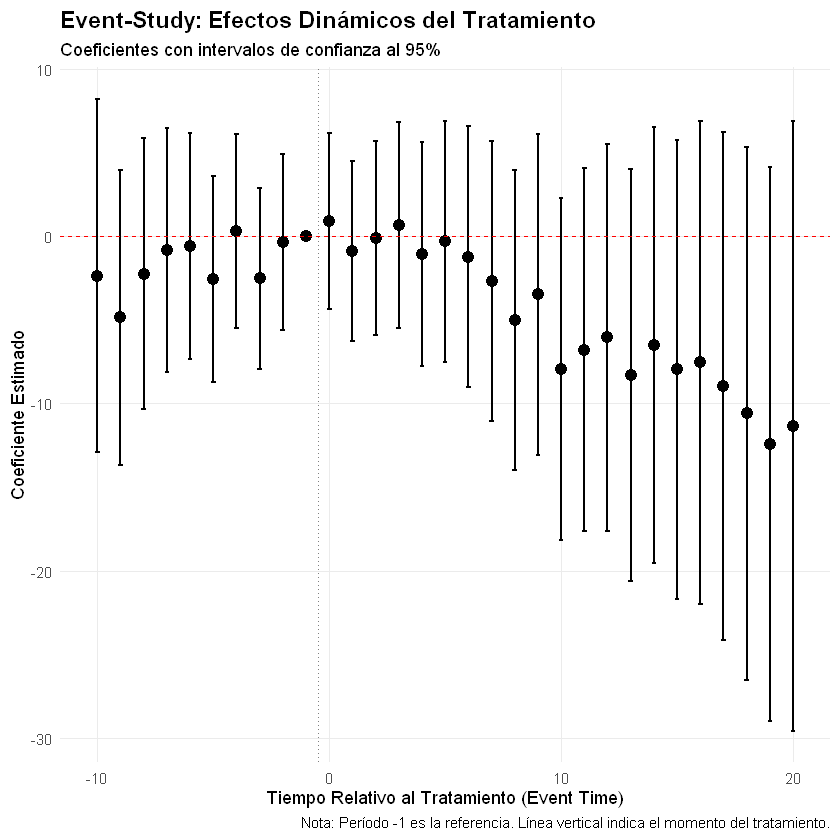

In [5]:
event_study_model <- feols(asmrs ~ i(event_time_binned, ref = -1) + 
                           pcinc + asmrh + cases | 
                           stfips + year, 
                           data = data_treated)

cat("\n=== RESULTADOS EVENT-STUDY ===\n")
summary(event_study_model)

coef_names <- names(coef(event_study_model))
event_coefs <- coef_names[grepl("event_time_binned", coef_names)]

results_df <- data.frame(
  event_time = as.numeric(gsub("event_time_binned::", "", event_coefs)),
  coefficient = coef(event_study_model)[event_coefs],
  se = se(event_study_model)[event_coefs]
)

results_df <- rbind(results_df, 
                    data.frame(event_time = -1, 
                              coefficient = 0, 
                              se = 0))
results_df <- results_df %>% arrange(event_time)

results_df <- results_df %>%
  mutate(
    ci_lower = coefficient - 1.96 * se,
    ci_upper = coefficient + 1.96 * se
  )

print("Coeficientes del Event-Study:")
print(results_df)

event_study_plot <- ggplot(results_df, aes(x = event_time, y = coefficient)) +
  geom_point(size = 3) +
  geom_errorbar(aes(ymin = ci_lower, ymax = ci_upper), 
                width = 0.2, 
                linewidth = 0.8) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  geom_vline(xintercept = -0.5, linetype = "dotted", color = "gray50") +
  labs(
    title = "Event-Study: Efectos Dinámicos del Tratamiento",
    subtitle = "Coeficientes con intervalos de confianza al 95%",
    x = "Tiempo Relativo al Tratamiento (Event Time)",
    y = "Coeficiente Estimado",
    caption = "Nota: Período -1 es la referencia. Línea vertical indica el momento del tratamiento."
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    axis.title = element_text(size = 11),
    panel.grid.minor = element_blank()
  )

print(event_study_plot)

# Question 2 — CSDiD

# a)

# b)

# c)

> Grupo: Calcula el efecto promedio del tratamiento para cada cohorte (grupo de estados tratados en el mismo año). En los datos hay 8 grupos tratados entre 1969 y 1977. Esta agregación responde: ¿qué cohorte tuvo el mayor/menor efecto? Por ejemplo, el grupo tratado en 1970 tiene un efecto de -30.65 
(muy negativo), mientras que el grupo de 1975 tiene +3.51 (positivo). Esto indica que el momento en que se recibió el tratamiento importa para los 
resultados.

> Periodo: Calcula el efecto promedio en cada año calendario específico (1969, 1970, 1971, etc.). Esta agregación responde: ¿en qué años el tratamiento tuvo mayor impacto agregado? En los datos, los efectos negativos más fuertes aparecen en los años 1990s (1990: -15.80, 1995: -20.01). Es útil para identificar períodos donde el efecto agregado fue particularmente fuerte o débil en tiempo absoluto.

> Event-time: Calcula el efecto promedio en cada período relativo al momento del tratamiento (-5 años antes, año 0, +3 años después, etc.). Esta agregación responde: ¿cómo evoluciona el efecto antes y después del tratamiento? Es la más comparable con el Event-Study TWFE porque ambos usan tiempo relativo. En los datos, los coeficientes pre-tratamiento son mayormente no significativos (validando tendencias paralelas), y los efectos negativos significativos aparecen muchos años después del tratamiento (event-time 21-26), indicando efectos de largo plazo.

> La agregación por EVENT-TIME es directamente comparable porque ambos métodos grafican efectos en tiempo relativo al tratamiento, permiten verificar tendencias paralelas pre-tratamiento, y muestran la dinámica temporal del efecto. La diferencia es que CSDiD permite heterogeneidad de efectos mientras TWFE asume homogeneidad.

# d)